# FAA Twitter Cleaning and Preprocessing

Team: Samanth Archie, Joel Atikemah, Lucas Huynh, Hetong Wang

We begin by loading the FAA tweet dataset, checking a few basic data-quality issues, and defining a clean working sample for later text analysis. For now, the emphasis is on the tweet text, but it helps to first understand the structure of the scraped data.

In [1]:
from pathlib import Path
import html
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 220)

### Loading in data

We first load the tweet-level data and inspect the columns that came back from the scrape.

In [2]:
# read in the data

data_path = Path('2025-2026 FAA Tweets/tweets_2025.csv')
df_raw = pd.read_csv(data_path)

print(f'rows: {len(df_raw):,}')
print(f'columns: {len(df_raw.columns)}')
print(sorted(df_raw.columns.tolist()))

rows: 4,372
columns: 16
['author.profilePicture', 'bookmarkCount', 'createdAt', 'id', 'isPinned', 'isQuote', 'isReply', 'lang', 'likeCount', 'quoteCount', 'replyCount', 'retweetCount', 'source', 'text', 'url', 'viewCount']


In [3]:
df_raw.head(3)

,id,url,text,createdAt,author.profilePicture,retweetCount,replyCount,likeCount,quoteCount,viewCount,bookmarkCount,source,lang,isReply,isQuote,isPinned
0,1994856060495015968,https://x.com/Fly_Nashville/status/1994856060495015968,UPDATE NOV. 29 1:45 P.M.| The Federal Aviation Administration (FAA) has lifted the ground delay program for Nashville International Airport® (BNA®) that was due to an air traffic control staffing shortage. Safe trave...,Sat Nov 29 19:48:42 +0000 2025,https://pbs.twimg.com/profile_images/1336766832431271940/fyVSbdl-_normal.jpg,1,0,8,1,12090,2,NaN,en,False,True,False
1,1990230659403551159,https://x.com/TimcastNews/status/1990230659403551159,"🚨 BREAKING: The FAA is ending its flight-cut mandates at 40 major airports, after controller staffing finally stabilized following the shutdown. \n\nAirlines can return to regular schedules on Monday morning, althoug...",Mon Nov 17 01:29:00 +0000 2025,https://pbs.twimg.com/profile_images/1952496567853658112/80xjOjwx_normal.jpg,5,4,82,0,6714,1,NaN,en,False,NaN,False
2,1994780036230959188,https://x.com/Fly_Nashville/status/1994780036230959188,UPDATE | The Federal Aviation Administration (FAA) has lifted the ground stop for incoming flights to Nashville International Airport® (BNA®) that was due to an air traffic control staffing shortage. Safe travels! #B...,Sat Nov 29 14:46:36 +0000 2025,https://pbs.twimg.com/profile_images/1336766832431271940/fyVSbdl-_normal.jpg,4,0,15,1,11812,0,NaN,en,False,True,False


### Basic checks

Before touching the text, it is useful to look at missingness, duplicates, language, and the observed date range.

In [4]:
missing = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'missing_pct': (100 * df_raw.isna().mean()).round(2)
}).sort_values('missing_count', ascending=False)

missing[missing['missing_count'] > 0]

,missing_count,missing_pct
source,4372,100.00
isQuote,3993,91.33


In [5]:
print('duplicate ids:', df_raw['id'].duplicated().sum())
print('duplicate urls:', df_raw['url'].duplicated().sum())
print('duplicate texts:', df_raw['text'].duplicated().sum())
print('fully duplicated rows:', df_raw.duplicated().sum())

duplicate ids: 2028
duplicate urls: 2028
duplicate texts: 2039
fully duplicated rows: 1832


In [6]:
dates = pd.to_datetime(
    df_raw['createdAt'],
    format='%a %b %d %H:%M:%S %z %Y',
    utc=True
)

print('date range:')
print(dates.min())
print(dates.max())
print()
print('tweets by year:')
print(dates.dt.year.value_counts().sort_index())
print()
print('language counts:')
print(df_raw['lang'].value_counts(dropna=False))

date range:
2023-01-11 18:24:40+00:00
2026-04-13 21:30:42+00:00

tweets by year:
createdAt
2023      42
2024     129
2025     778
2026    3423
Name: count, dtype: int64

language counts:
lang
en    4371
fr       1
Name: count, dtype: int64


### Defining the analysis sample

A few choices are worth making explicit:

- parse the timestamp once and keep a few calendar features
- fill the boolean flag columns where missing means `False`
- deduplicate by tweet ID, keeping the richest engagement snapshot when the same tweet appears more than once
- focus on English-language tweets from 2025 onward to match the intended project window

In [7]:
# clean up the structured fields

df = df_raw.copy()
df['createdAt'] = pd.to_datetime(
    df['createdAt'],
    format='%a %b %d %H:%M:%S %z %Y',
    utc=True
)

for col in ['isReply', 'isQuote', 'isPinned']:
    df[col] = df[col].where(df[col].notna(), False).astype(bool)

engagement_cols = ['viewCount', 'likeCount', 'retweetCount', 'replyCount', 'quoteCount', 'bookmarkCount']
df = (df
      .sort_values(['id'] + engagement_cols)
      .drop_duplicates(subset='id', keep='last')
      .copy())

df['date'] = df['createdAt'].dt.date
df['year_month'] = df['createdAt'].dt.strftime('%Y-%m')
df['hour'] = df['createdAt'].dt.hour

analysis_df = df[(df['lang'] == 'en') & (df['createdAt'] >= '2025-01-01')].copy()

summary = pd.Series({
    'raw_rows': len(df_raw),
    'after_dedup_by_id': len(df),
    'analysis_rows': len(analysis_df),
    'dropped_before_2025_or_non_english': len(df) - len(analysis_df)
})
summary

raw_rows                              4372
after_dedup_by_id                     2344
analysis_rows                         2173
dropped_before_2025_or_non_english     171
dtype: int64

In [8]:
analysis_df[['id', 'createdAt', 'lang', 'isReply', 'isQuote', 'text']].head(5)

,id,createdAt,lang,isReply,isQuote,text
2834,1875180326932324440,2025-01-03 14:00:03+00:00,en,False,False,"The Federal Aviation Administration's tougher oversight of Boeing will continue indefinitely, the agency's outgoing head said Friday. https://t.co/JqIooCbYlA"
2958,1881126875164025171,2025-01-19 23:49:31+00:00,en,False,False,"Biden’s Aviation Legacy: Infrastructure Funding, FAA Oversight, and Boeing Scrutiny https://t.co/NutlVgn2aQ"
2960,1881190421268996475,2025-01-20 04:02:01+00:00,en,False,False,"Biden’s Aviation Legacy: Infrastructure Funding, FAA Oversight, and Boeing Scrutiny https://t.co/csdWBTGtjb"
4221,1882545214700564876,2025-01-23 21:45:29+00:00,en,False,False,"Ever wonder why trucks spray steaming liquid on planes before takeoff in winter? Deicing removes ice, snow or frost that can affect a plane’s performance. While it may cause delays, it’s essential for safety. Get rea..."
2909,1885086018115649826,2025-01-30 22:01:44+00:00,en,False,False,"“The next administrator needs to be ready day one to continue the job of restoring the FAA’s safety culture and providing real oversight of the aviation sector,” Sen. Maria Cantwell (D-Wash.) \n\nIt appears they were..."


### Basic EDA on the structured columns

These plots are mainly meant to give us a feel for the sample we will analyze next.

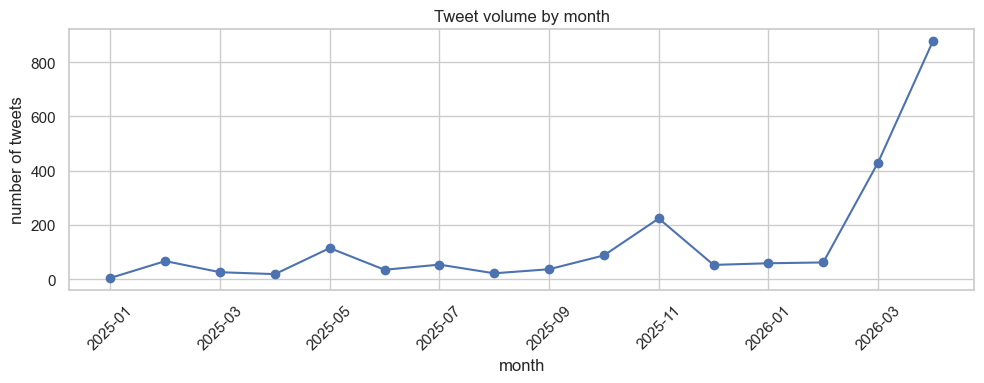

In [9]:
monthly_counts = (analysis_df['year_month']
                  .value_counts()
                  .sort_index())

plt.figure(figsize=(10, 4))
monthly_counts.plot(marker='o')
plt.title('Tweet volume by month')
plt.xlabel('month')
plt.ylabel('number of tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
reply_quote_summary = pd.Series({
    'reply_share': analysis_df['isReply'].mean(),
    'quote_share': analysis_df['isQuote'].mean(),
    'median_views': analysis_df['viewCount'].median(),
    'median_likes': analysis_df['likeCount'].median(),
    'median_retweets': analysis_df['retweetCount'].median()
}).round(3)

reply_quote_summary

reply_share          0.172
quote_share          0.074
median_views       319.000
median_likes         1.000
median_retweets      0.000
dtype: float64

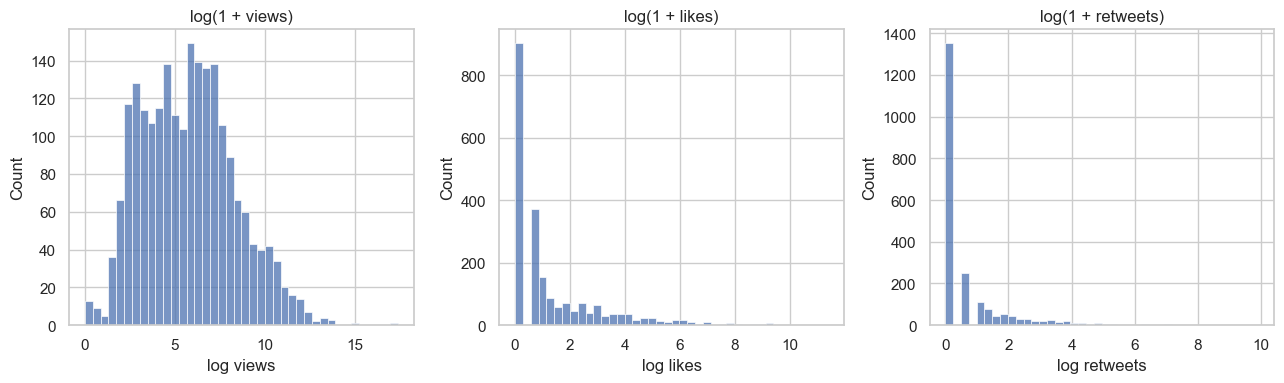

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sns.histplot(np.log1p(analysis_df['viewCount']), bins=40, ax=axes[0])
axes[0].set_title('log(1 + views)')
axes[0].set_xlabel('log views')

sns.histplot(np.log1p(analysis_df['likeCount']), bins=40, ax=axes[1])
axes[1].set_title('log(1 + likes)')
axes[1].set_xlabel('log likes')

sns.histplot(np.log1p(analysis_df['retweetCount']), bins=40, ax=axes[2])
axes[2].set_title('log(1 + retweets)')
axes[2].set_xlabel('log retweets')

plt.tight_layout()
plt.show()

In [12]:
# look at a few of the highest-engagement tweets

analysis_df.sort_values('viewCount', ascending=False)[[
    'createdAt', 'viewCount', 'likeCount', 'retweetCount', 'replyCount', 'text'
]].head(10)

,createdAt,viewCount,likeCount,retweetCount,replyCount,text
437,2025-02-18 01:12:17+00:00,36077130,89943,20129,9518,"Mayor Pete failed for four years to address the air traffic controller shortage and upgrade our outdated, World War II-era air traffic control system. In less than four weeks, we have already begun the process and ar..."
3628,2026-04-10 14:31:09+00:00,3197632,9528,1000,630,"🚨👀 Watch this…\n\nYOU can be the future of air traffic control\n\nIt’s not a GAME, its a CAREER \n\nApplications open April 17th at Midnight @FAANews https://t.co/JVpgCIeF58"
28,2026-03-23 08:10:36+00:00,938463,6979,1809,503,"If FAA staffing shortages turn out to be a key aspect of this horrible tragedy, remember that @elonmusk\n and his “Doge” department fired hundreds of FAA staffers last year - including safety workers, and even tried ..."
1072,2025-11-06 02:42:34+00:00,861448,2709,584,159,"Due to the ongoing government shutdown and nationwide air traffic control staffing shortages, the FAA has directed airlines to reduce flight schedules to maintain safe airspace operations starting Friday, Nov. 7.\n\n..."
1716,2025-02-17 21:46:27+00:00,728845,8498,1278,4135,NBC REPORTER ON PLANE CRASH: There has been talk about staff cuts at the FAA as a part of President Trump's effort to trim down the federal workforce. The FAA has been complaining for years that they are understaffed...
2535,2026-03-27 19:13:00+00:00,714584,2386,394,237,"""The pilots sacrificed themselves to save everybody.""\n\nCaptain Steeeve says the ""heroic"" Air Canada pilots involved in the LaGuardia plane crash ""could have veered left or right to avoid harm for them in the cockpi..."
2513,2026-03-27 21:37:05+00:00,606497,10056,1804,209,Incredible heroism revealed. An aviation expert explains how the pilots in the LaGuardia crash intentionally took the impact head on. They refused to veer away to prevent the fuel filled wings from hitting the truck ...
2726,2026-03-26 22:24:12+00:00,526913,1275,153,27,The FAA says its investigation of the incident involving United flight 589 and a US Army Black Hawk will also include “whether a new measure to suspend the use of visual separation between airplanes and helicopters w...
2687,2026-01-28 09:35:45+00:00,494404,2076,112,20,"These are medium-intensity red aviation obstruction lights, called L-864, used to mark tall structures for aircraft safety. \n\nThey flash 20–40 times per minute, meet FAA/ICAO standards, and offer infrared visibilit..."
2665,2026-01-30 20:02:07+00:00,338263,343,25,5,"Laser strikes on aircraft are a serious threat to aviation safety, and pointing a laser at an aircraft is a federal crime. Know the safety risks and penalties, report strikes to the FAA and law enforcement and help u..."


### Preprocessing the text column

For the text, we keep two versions:

- `text_clean`: a lightly normalized version of the original tweet text
- `text_lemma`: a lemmatized version that should be convenient for later n-grams, topic modeling, and clustering

The basic cleaning below removes URLs and mentions, keeps hashtag words, lowercases, normalizes whitespace, and preserves apostrophes so negation is not lost too early.

In [13]:
url_pattern = re.compile(r'https?://\S+|www\.\S+')
mention_pattern = re.compile(r'@\w+')
hashtag_pattern = re.compile(r'#(\w+)')
extra_space_pattern = re.compile(r'\s+')
non_text_pattern = re.compile(r"[^a-z0-9'\s]")


def basic_clean(text):
    text = html.unescape(str(text))
    text = text.replace('\n', ' ')
    text = text.replace('’', "'")
    text = url_pattern.sub(' ', text)
    text = hashtag_pattern.sub(r' \1 ', text)
    text = mention_pattern.sub(' ', text)
    text = text.lower()
    text = non_text_pattern.sub(' ', text)
    text = extra_space_pattern.sub(' ', text).strip()
    return text

In [14]:
analysis_df['text_clean'] = analysis_df['text'].map(basic_clean)
analysis_df[['text', 'text_clean']].head(8)

,text,text_clean
2834,"The Federal Aviation Administration's tougher oversight of Boeing will continue indefinitely, the agency's outgoing head said Friday. https://t.co/JqIooCbYlA",the federal aviation administration's tougher oversight of boeing will continue indefinitely the agency's outgoing head said friday
2958,"Biden’s Aviation Legacy: Infrastructure Funding, FAA Oversight, and Boeing Scrutiny https://t.co/NutlVgn2aQ",biden's aviation legacy infrastructure funding faa oversight and boeing scrutiny
2960,"Biden’s Aviation Legacy: Infrastructure Funding, FAA Oversight, and Boeing Scrutiny https://t.co/csdWBTGtjb",biden's aviation legacy infrastructure funding faa oversight and boeing scrutiny
4221,"Ever wonder why trucks spray steaming liquid on planes before takeoff in winter? Deicing removes ice, snow or frost that can affect a plane’s performance. While it may cause delays, it’s essential for safety. Get rea...",ever wonder why trucks spray steaming liquid on planes before takeoff in winter deicing removes ice snow or frost that can affect a plane's performance while it may cause delays it's essential for safety get real tim...
2909,"“The next administrator needs to be ready day one to continue the job of restoring the FAA’s safety culture and providing real oversight of the aviation sector,” Sen. Maria Cantwell (D-Wash.) \n\nIt appears they were...",the next administrator needs to be ready day one to continue the job of restoring the faa's safety culture and providing real oversight of the aviation sector sen maria cantwell d wash it appears they were not ready ...
4328,".@Smerconish - @BillAckman Spoke w/ ex-Blackhawk pilot now at major airline. He attributes DC crash to series of errors: inadequate tower info, staffing, NVG use, and FAA delays on safety. Urges focus on merit over q...",spoke w ex blackhawk pilot now at major airline he attributes dc crash to series of errors inadequate tower info staffing nvg use and faa delays on safety urges focus on merit over quotas in aviation let's make this ...
4219,@super_ultraMAGA @LeadingReport 1. You can't be deaf or blind and control air traffic.\n2. You can't be stupid and control air traffic.\nWho wrote that legislation?,1 you can't be deaf or blind and control air traffic 2 you can't be stupid and control air traffic who wrote that legislation
4307,"The NOTAM system, which provides flight safety updates, is currently experiencing an outage. However, a backup system is operational, and no immediate disruptions to air travel have been reported. The FAA is investig...",the notam system which provides flight safety updates is currently experiencing an outage however a backup system is operational and no immediate disruptions to air travel have been reported the faa is investigating ...


The preprocessing demos in class use spaCy lemmatization, so we follow that same general pattern here.

In [15]:
# lemmatize the cleaned text

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


def lemmatize_texts(texts, batch_size=64):
    docs = []
    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size), total=len(texts)):
        tokens = [token.lemma_ for token in doc if not token.is_space and not token.is_punct]
        docs.append(' '.join(tokens))
    return docs


analysis_df['text_lemma'] = lemmatize_texts(analysis_df['text_clean'].tolist())
analysis_df['n_tokens_clean'] = analysis_df['text_clean'].str.split().str.len()
analysis_df['n_tokens_lemma'] = analysis_df['text_lemma'].str.split().str.len()

  0%|          | 0/2173 [00:00<?, ?it/s]

In [16]:
analysis_df[['text', 'text_clean', 'text_lemma']].sample(5, random_state=0)

,text,text_clean,text_lemma
3780,#News The legislation modernizes air traffic control systems after failures under the previous administration—promising safer skies through a complete overhaul so Americans can fly more safely and efficiently.,news the legislation modernizes air traffic control systems after failures under the previous administration promising safer skies through a complete overhaul so americans can fly more safely and efficiently,news the legislation modernize air traffic control system after failure under the previous administration promise safe sky through a complete overhaul so americans can fly more safely and efficiently
1044,"The experience of traveling in/out of EWR this summer feels like a game of chance. Flights are coming and going. But if your flight gets caught up in air traffic control staffing shortage delays, what a miserable exp...",the experience of traveling in out of ewr this summer feels like a game of chance flights are coming and going but if your flight gets caught up in air traffic control staffing shortage delays what a miserable experi...,the experience of travel in out of ewr this summer feel like a game of chance flight be come and go but if your flight get catch up in air traffic control staffing shortage delay what a miserable experience it can be...
2384,Air Canada CEO Michael Rousseau to step down in 2026 for failing to speak French. Quebec’s legislature passed a vote demanding him to resign over his failure to speak French in a video about deadly collision at LaGua...,air canada ceo michael rousseau to step down in 2026 for failing to speak french quebec's legislature passed a vote demanding him to resign over his failure to speak french in a video about deadly collision at laguar...,air canada ceo michael rousseau to step down in 2026 for fail to speak french quebec 's legislature pass a vote demand he to resign over his failure to speak french in a video about deadly collision at laguardia airport
4110,"You can apply right now for FAA Air Traffic Control Specialist - Trainee jobs on https://t.co/V4XMesLG6A. Search ""Air Traffic Control Specialist - Trainee (Direct Hire)"". \n\nIt's open until June 26, 2026 (or until t...",you can apply right now for faa air traffic control specialist trainee jobs on search air traffic control specialist trainee direct hire it's open until june 26 2026 or until they hit 8 000 apps must be a u s citizen...,you can apply right now for faa air traffic control specialist trainee job on search air traffic control specialist trainee direct hire it be open until june 26 2026 or until they hit 8 000 app must be a u s citizen ...
560,"Air Traffic Controller Shortage: Gamers Could Be the Solution\n\nAir traffic controller shortage has become a growing concern, and authorities are now exploring an unexpected solution—gamers. \n\nDETAILS: https://t.c...",air traffic controller shortage gamers could be the solution air traffic controller shortage has become a growing concern and authorities are now exploring an unexpected solution gamers details,air traffic controller shortage gamer could be the solution air traffic controller shortage have become a grow concern and authority be now explore an unexpected solution gamer detail


In [17]:
analysis_df[['n_tokens_clean', 'n_tokens_lemma']].describe().round(2)

,n_tokens_clean,n_tokens_lemma
count,2173.00,2173.00
mean,35.28,35.83
std,47.12,47.90
min,1.00,1.00
25%,16.00,16.00
50%,28.00,28.00
75%,40.00,41.00
max,1289.00,1315.00


### Saving the cleaned data

We save the working dataframe so the later notebooks can start from the cleaned text rather than repeating the same preprocessing.

In [18]:
output_path = Path('2025-2026 FAA Tweets/tweets_2025_analysis_ready.csv')
analysis_df.to_csv(output_path, index=False)

print(output_path)

2025-2026 FAA Tweets/tweets_2025_analysis_ready.csv
